In [38]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Dispositivo: {device}")
print(f"PyTorch: {torch.__version__} ✅")

Dispositivo: mps
PyTorch: 2.8.0 ✅


In [39]:
df = pd.read_csv('../data/creditcard.csv')

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

feature_cols = [c for c in df.columns if c not in ['Class', 'Time', 'Amount']]
X = df[feature_cols].values
y = df['Class'].values

print(f"Shape X: {X.shape}")
print(f"Fraudes: {y.sum()} ({y.mean()*100:.3f}%)")

Shape X: (284807, 30)
Fraudes: 492 (0.173%)


In [40]:
# El Autoencoder aprende SOLO el patrón de transacciones normales
# En inferencia, las fraudulentas tendrán alto error de reconstrucción
X_normal = X[y == 0]
X_fraud = X[y == 1]

print(f"Transacciones normales para entrenamiento: {len(X_normal):,}")
print(f"Transacciones fraudulentas (solo para evaluación): {len(X_fraud):,}")

# Split del conjunto normal
X_train, X_val = train_test_split(X_normal, test_size=0.1, random_state=42)

# Test set: mezcla de normales y fraudes
X_test = np.vstack([X_val, X_fraud])
y_test = np.hstack([np.zeros(len(X_val)), np.ones(len(X_fraud))])

print(f"\nTrain (solo normales): {X_train.shape}")
print(f"Test (normales + fraudes): {X_test.shape}")
print(f"Fraudes en test: {y_test.sum():.0f} ✅")

Transacciones normales para entrenamiento: 284,315
Transacciones fraudulentas (solo para evaluación): 492

Train (solo normales): (255883, 30)
Test (normales + fraudes): (28924, 30)
Fraudes en test: 492 ✅


In [41]:
class FraudDataset(Dataset):
    def __init__(self, X):
        self.X = torch.FloatTensor(X)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx]

train_dataset = FraudDataset(X_train)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

print(f"Batches de entrenamiento: {len(train_loader)} ✅")

Batches de entrenamiento: 1000 ✅


In [42]:
class FraudAutoencoder(nn.Module):
    """
    Autoencoder para detección de anomalías.
    
    Encoder: comprime 30 features → 8 (representación latente)
    Decoder: reconstruye 8 → 30 features
    
    Lógica: entrenado solo con transacciones normales,
    aprende a reconstruirlas bien. Las fraudulentas
    tienen un patrón diferente → error de reconstrucción alto.
    """
    def __init__(self, input_dim=30):
        super().__init__()

        # Encoder — comprime la información
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.BatchNorm1d(16),
            nn.Dropout(0.2),
            nn.Linear(16, 8),
            nn.ReLU(),
        )

        # Decoder — reconstruye la información
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.BatchNorm1d(16),
            nn.Dropout(0.2),
            nn.Linear(16, input_dim),
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

INPUT_DIM = X_train.shape[1]
model = FraudAutoencoder(input_dim=INPUT_DIM).to(device)
print(model)
print(f"\nParámetros: {sum(p.numel() for p in model.parameters()):,} ✅")

FraudAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=30, out_features=16, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=16, out_features=30, bias=True)
  )
)

Parámetros: 1,350 ✅


Entrenando Autoencoder...

Epoch 10/50 | Loss: 0.539539
Epoch 20/50 | Loss: 0.533495
Epoch 30/50 | Loss: 0.527381
Epoch 40/50 | Loss: 0.525835
Epoch 50/50 | Loss: 0.517340

Entrenamiento completo ✅


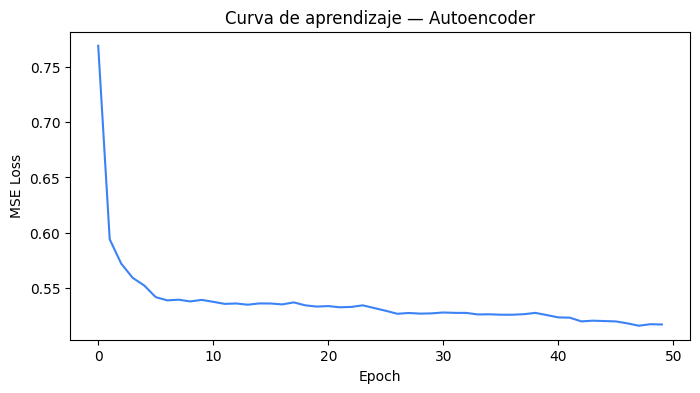

In [43]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

EPOCHS = 50
train_losses = []

print("Entrenando Autoencoder...\n")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for X_batch in train_loader:
        X_batch = X_batch.to(device)
        optimizer.zero_grad()
        reconstructed = model(X_batch)
        loss = criterion(reconstructed, X_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:2d}/{EPOCHS} | Loss: {avg_loss:.6f}")

print("\nEntrenamiento completo ✅")

plt.figure(figsize=(8, 4))
plt.plot(train_losses, color='#3b82f6')
plt.title('Curva de aprendizaje — Autoencoder')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.savefig('../data/training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

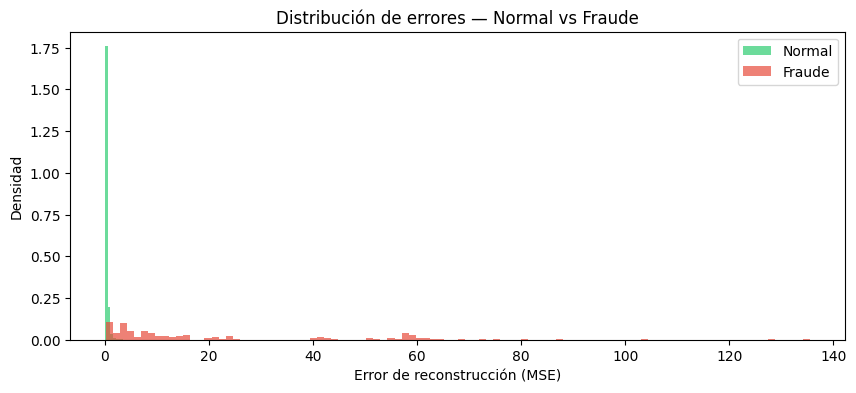

Error promedio normales: 0.3769
Error promedio fraudes:  19.1036


In [44]:
model.eval()
X_test_tensor = torch.FloatTensor(X_test).to(device)

with torch.no_grad():
    X_reconstructed = model(X_test_tensor).cpu().numpy()

# Error de reconstrucción por transacción
reconstruction_errors = np.mean((X_test - X_reconstructed) ** 2, axis=1)

# Distribución de errores
plt.figure(figsize=(10, 4))
plt.hist(reconstruction_errors[y_test == 0], bins=100,
         alpha=0.7, color='#2ecc71', label='Normal', density=True)
plt.hist(reconstruction_errors[y_test == 1], bins=100,
         alpha=0.7, color='#e74c3c', label='Fraude', density=True)
plt.xlabel('Error de reconstrucción (MSE)')
plt.ylabel('Densidad')
plt.title('Distribución de errores — Normal vs Fraude')
plt.legend()
plt.savefig('../data/reconstruction_errors.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Error promedio normales: {reconstruction_errors[y_test==0].mean():.4f}")
print(f"Error promedio fraudes:  {reconstruction_errors[y_test==1].mean():.4f}")

Umbral óptimo: 3.9326 | F1 fraude: 0.7516

=== MÉTRICAS ===

              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     28432
      Fraude       0.80      0.71      0.75       492

    accuracy                           0.99     28924
   macro avg       0.90      0.85      0.87     28924
weighted avg       0.99      0.99      0.99     28924

AUC-ROC: 0.9643


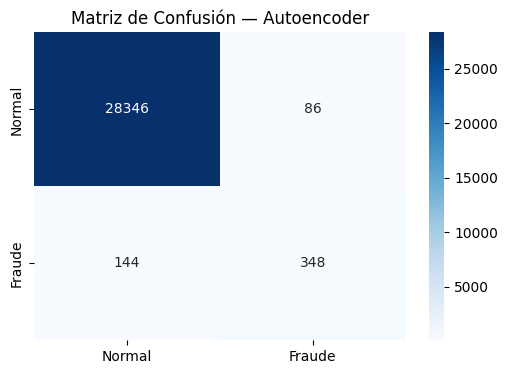

In [45]:
thresholds = np.percentile(reconstruction_errors, np.arange(80, 100, 0.5))
f1_scores = [f1_score(y_test, (reconstruction_errors >= t).astype(int), pos_label=1)
             for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
y_pred = (reconstruction_errors >= best_threshold).astype(int)

print(f"Umbral óptimo: {best_threshold:.4f} | F1 fraude: {max(f1_scores):.4f}")
print("\n=== MÉTRICAS ===\n")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraude']))
print(f"AUC-ROC: {roc_auc_score(y_test, reconstruction_errors):.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.title('Matriz de Confusión — Autoencoder')
plt.savefig('../data/confusion_matrix_autoencoder.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
torch.save(model.state_dict(), '../data/fraud_autoencoder.pt')
joblib.dump(scaler, '../data/scaler.pkl')
joblib.dump(feature_cols, '../data/feature_cols.pkl')
joblib.dump(best_threshold, '../data/best_threshold.pkl')

print("Modelo guardado en data/fraud_autoencoder.pt ✅")
print(f"Umbral óptimo guardado: {best_threshold:.4f} ✅")

Modelo guardado en data/fraud_autoencoder.pt ✅
Umbral óptimo guardado: 3.9326 ✅
